In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("="*50)
print("SHAPE")
print("="*50)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\n" + "="*50)
print("TRAIN HEAD (أول 5 صفوف)")
print("="*50)
print(train.head())


SHAPE
Train shape: (891, 12)
Test shape: (418, 11)

TRAIN HEAD (أول 5 صفوف)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1

In [5]:

print("\n" + "="*50)
print("TRAIN INFO")
print("="*50)
print(train.info())

print("\n" + "="*50)
print("TRAIN DESCRIBE")
print("="*50)
print(train.describe())

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(train.isnull().sum())


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

TRAIN DESCRIBE
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
s

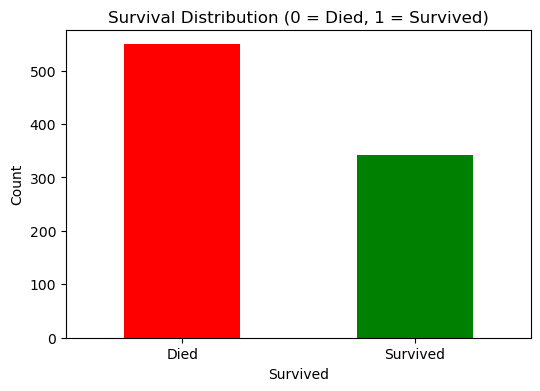

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. توزيع الـ Target (Survived)
plt.figure(figsize=(6,4))
train['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0, 1], ['Died', 'Survived'], rotation=0)
plt.show()


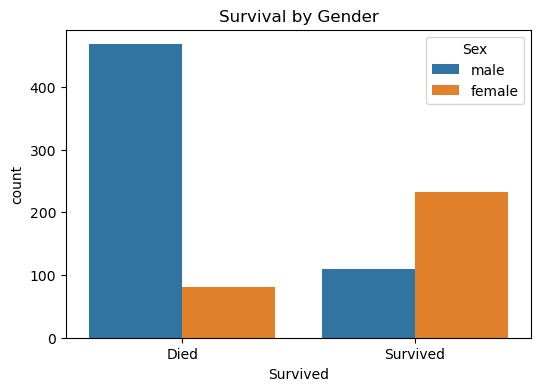

In [7]:

# 2. الجنس والنجاة
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Sex', data=train)
plt.title('Survival by Gender')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()


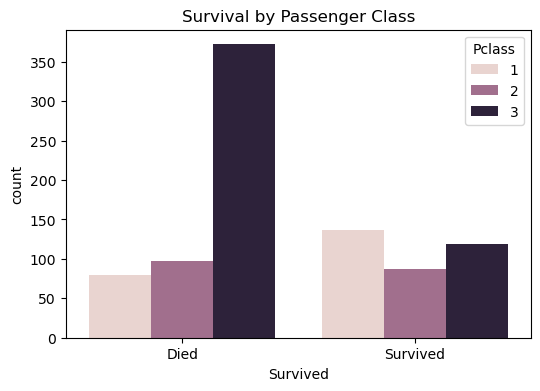

In [8]:

# 3. الدرجة والنجاة
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', hue='Pclass', data=train)
plt.title('Survival by Passenger Class')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()


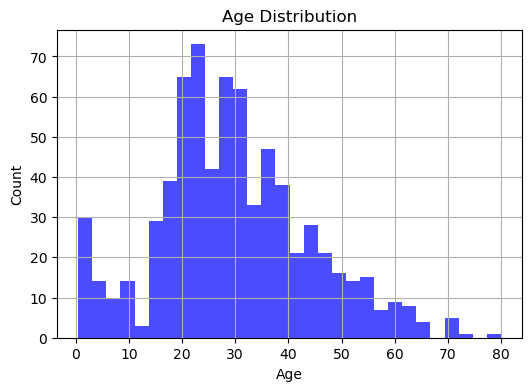

In [9]:

# 4. توزيع الأعمار
plt.figure(figsize=(6,4))
train['Age'].hist(bins=30, alpha=0.7, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


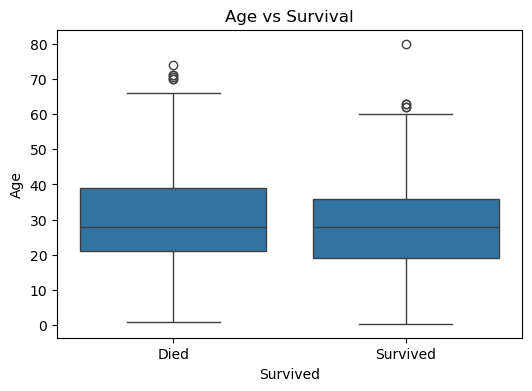

In [10]:

# 5. العمر والنجاة
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=train)
plt.title('Age vs Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()


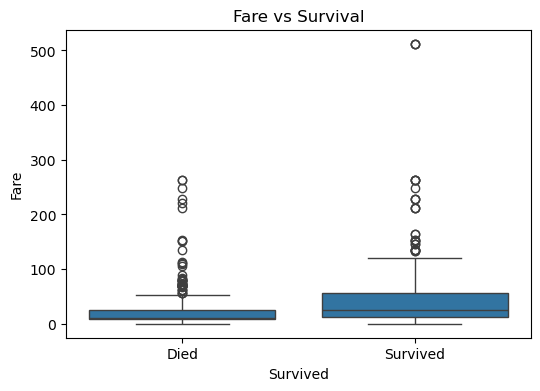

In [11]:

# 6. السعر والنجاة
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Fare', data=train)
plt.title('Fare vs Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()


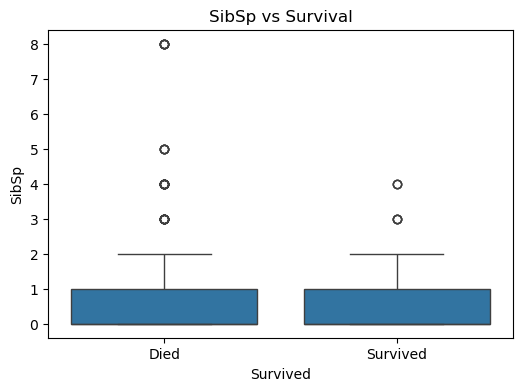

In [12]:

# 7. عدد الأخوة/الأزواج والنجاة
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='SibSp', data=train)
plt.title('SibSp vs Survival')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()


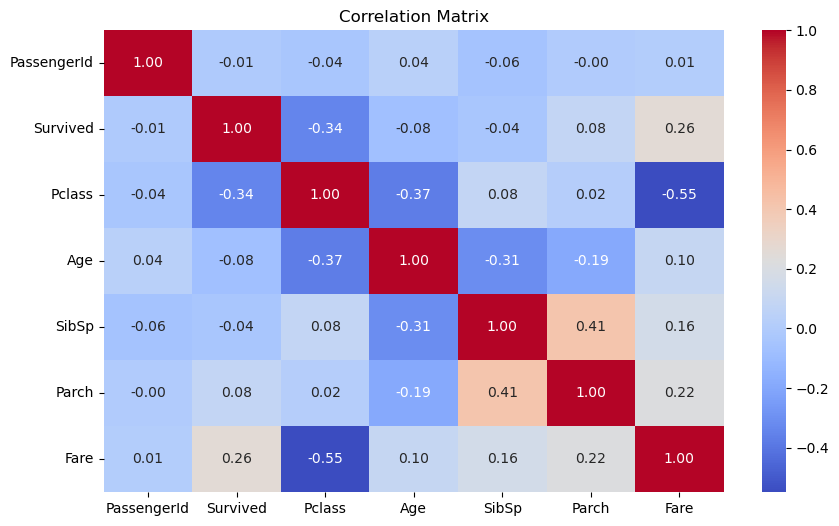

In [13]:

# 8. مصفوفة الارتباط (Correlation Matrix)
plt.figure(figsize=(10,6))
numeric_cols = train.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

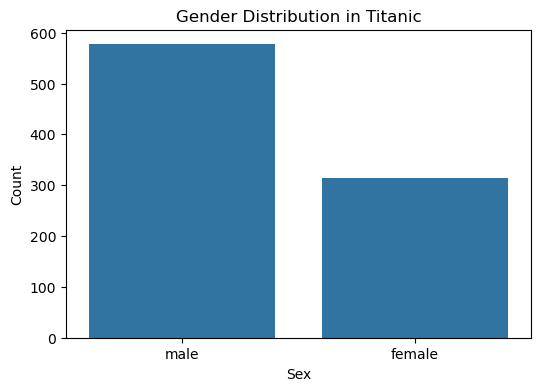

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=train)
plt.title('Gender Distribution in Titanic')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

In [15]:
train['Title'] = train['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
train['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [16]:
train.groupby('Title')['Survived'].mean().sort_values(ascending=False)


Title
the Countess    1.000000
Mlle            1.000000
Sir             1.000000
Ms              1.000000
Lady            1.000000
Mme             1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Col             0.500000
Major           0.500000
Dr              0.428571
Mr              0.156673
Jonkheer        0.000000
Rev             0.000000
Don             0.000000
Capt            0.000000
Name: Survived, dtype: float64

In [17]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1  # +1 للراكب نفسه
train.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [ ]:
# Step 3: Feature Engineering and Data Cleaning

train_clean = train.copy()
test_clean = test.copy()

for df in [train_clean, test_clean]:
    # Extract title from name
    df['Title'] = df['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()
    df['Title'] = df['Title'].replace(['Mme', 'Ms', 'Mlle'], 'Miss')
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Dona'], 'Mrs')
    df['Title'] = df['Title'].replace(['Capt', 'Col', 'Don', 'Jonkheer', 'Major', 'Rev', 'Sir', 'Dr'], 'Rare')

    # Family and cabin features
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['has_cabin'] = df['Cabin'].notna().astype(int)
    df['Deck'] = df['Cabin'].fillna('U').astype(str).str[0]

    # Fill missing values
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Age'] = df['Age'].fillna(df['Age'].median())

    # Create bins and frequency features
    df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 120], labels=[0, 1, 2, 3, 4]).astype(int)
    df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=[0, 1, 2, 3]).astype(int)
    df['TicketFreq'] = df.groupby('Ticket')['Ticket'].transform('count')

    # Improve age fill using title and class
    df['Age'] = df.groupby(['Pclass', 'Title'])['Age'].transform(lambda s: s.fillna(s.median()))
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Keep test ids for final submission
submission_ids = test_clean['PassengerId'].copy()

drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_clean = train_clean.drop(columns=drop_cols)
test_clean = test_clean.drop(columns=drop_cols)

# Encode categorical fields
train_clean['Sex'] = train_clean['Sex'].map({'male': 0, 'female': 1})
test_clean['Sex'] = test_clean['Sex'].map({'male': 0, 'female': 1})

train_clean['Embarked'] = train_clean['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})
test_clean['Embarked'] = test_clean['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
train_clean['Title'] = train_clean['Title'].map(title_mapping).fillna(0).astype(int)
test_clean['Title'] = test_clean['Title'].map(title_mapping).fillna(0).astype(int)

deck_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'U': 7}
train_clean['Deck'] = train_clean['Deck'].map(deck_mapping).fillna(7).astype(int)
test_clean['Deck'] = test_clean['Deck'].map(deck_mapping).fillna(7).astype(int)

# Consistent feature list used throughout the notebook
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title',
            'FamilySize', 'IsAlone', 'has_cabin', 'Deck', 'AgeBin', 'FareBin', 'TicketFreq']

X = train_clean[features].copy()
y = train_clean['Survived'].copy()

print("Cleaned training data shape:", train_clean.shape)
print("Cleaned test data shape:", test_clean.shape)
print("Missing values after cleaning:")
print(train_clean.isnull().sum())


Missing values in train:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
Title         0
FamilySize    0
IsAlone       0
has_cabin     0
dtype: int64

Missing values in test:
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          1
Embarked      0
Title         0
FamilySize    0
IsAlone       0
has_cabin     0
dtype: int64

Train cleaned:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
0         0       3    0  22.0      1      0   7.2500         2      0   
1         1       1    1  38.0      1      0  71.2833         0      2   
2         1       3    1  26.0      0      0   7.9250         2      1   
3         1       1    1  35.0      1      0  53.1000         2      2   
4         0       3    0  35.0      0      0   8.0500         2      0   

   FamilySize  IsAlone  has_cabin  
0           2        0          0  
1           2        0 

In [ ]:
# Step 4: Define the full preprocessing pipeline

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define feature groups
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'AgeBin', 'FareBin', 'TicketFreq']
cat_cols = ['Sex', 'Embarked', 'Title', 'IsAlone', 'has_cabin', 'Deck']
ord_cols = ['Pclass']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('ord', ord_pipeline, ord_cols)
])

print("Preprocessor configured successfully.")

# Step 5: Train and evaluate models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=5000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300, min_samples_leaf=2),
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred):.4f}")
    print(f"F1: {f1_score(y_val, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

# Step 6: Evaluate with cross-validation
print("\n" + "=" * 50)
print("Cross-Validation (10-fold)")
print("=" * 50)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    cv_scores = cross_val_score(pipeline, X, y, cv=10, scoring='accuracy')
    print(f"{name}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Step 7: GridSearch for SVC
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': [0.01, 0.1, 1, 'scale'],
    'classifier__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    svc_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 50)
print("Best SVC Parameters")
print("=" * 50)
print(grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_val)

print("\n" + "=" * 50)
print("Best SVC Performance on Validation Set")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_best):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_best))

# Step 8: Final predictions on test set
final_test = test_clean[features].copy()
final_predictions = best_model.predict(final_test)

submission = pd.DataFrame({
    'PassengerId': submission_ids.reset_index(drop=True),
    'Survived': final_predictions.astype(int)
})

submission.head()


In [20]:

X = train_clean[features].copy()
y = train_clean['Survived'].copy()

# ============================================
# 3. تقسيم Train / Validation
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_val distribution:\n{y_val.value_counts()}")


X_train shape: (712, 11)
X_val shape: (179, 11)
y_train distribution:
Survived
0    439
1    273
Name: count, dtype: int64
y_val distribution:
Survived
0    110
1     69
Name: count, dtype: int64


In [21]:

# ============================================
# 4. تحديد أنواع الأعمدة
# ============================================

# أعمدة رقمية (هنطبق عليها StandardScaler)
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']

# أعمدة Categorical (هنطبق عليها OneHotEncoder)
cat_cols = ['Sex', 'Embarked', 'Title', 'IsAlone', 'has_cabin']

# أعمدة Ordinal (Pclass لها ترتيب)
ord_cols = ['Pclass']

# ============================================
# 5. بناء الـ Pipelines
# ============================================

# Numerical Pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ordinal Pipeline (Pclass)
ord_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])


In [22]:

# ============================================
# 6. الـ ColumnTransformer (الدمج)
# ============================================

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
    ('ord', ord_pipeline, ord_cols)
])


In [23]:

# ============================================
# 7. تدريب النماذج
# ============================================

# 7.1 Logistic Regression
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
y_pred_log = log_pipeline.predict(X_val)

print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_log):.4f}")
print(f"F1: {f1_score(y_val, y_pred_log):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_log))


LOGISTIC REGRESSION
Accuracy: 0.8380
Precision: 0.8030
Recall: 0.7681
F1: 0.7852

Confusion Matrix:
[[97 13]
 [16 53]]


In [24]:

# 7.2 Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_val)

print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_val, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))



RANDOM FOREST
Accuracy: 0.7709
Precision: 0.7059
Recall: 0.6957
F1: 0.7007

Confusion Matrix:
[[90 20]
 [21 48]]


In [25]:

# 7.3 SVC
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, kernel='rbf', C=1.0, gamma='scale'))
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_val)

print("\n" + "="*50)
print("SVC")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_svc):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_svc):.4f}")
print(f"F1: {f1_score(y_val, y_pred_svc):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_svc))



SVC
Accuracy: 0.8380
Precision: 0.8125
Recall: 0.7536
F1: 0.7820

Confusion Matrix:
[[98 12]
 [17 52]]


In [26]:

# ============================================
# 8. Cross-Validation (التقييم العادل)
# ============================================

print("\n" + "="*50)
print("CROSS-VALIDATION (10 folds)")
print("="*50)

# Logistic Regression
log_cv = cross_val_score(log_pipeline, X, y, cv=10, scoring='accuracy')
print(f"Logistic Regression CV Accuracy: {log_cv.mean():.4f} ± {log_cv.std():.4f}")

# Random Forest
rf_cv = cross_val_score(rf_pipeline, X, y, cv=10, scoring='accuracy')
print(f"Random Forest CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

# SVC
svc_cv = cross_val_score(svc_pipeline, X, y, cv=10, scoring='accuracy')
print(f"SVC CV Accuracy: {svc_cv.mean():.4f} ± {svc_cv.std():.4f}")


CROSS-VALIDATION (10 folds)
Logistic Regression CV Accuracy: 0.8294 ± 0.0292
Random Forest CV Accuracy: 0.8104 ± 0.0502
SVC CV Accuracy: 0.8317 ± 0.0365


In [27]:
# ============================================
# 1. استيراد المكتبات المطلوبة
# ============================================
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ============================================
# 2. تجهيز X و y
# ============================================

# اختيار الميزات (من بعد التنظيف)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'has_cabin']

X = train_clean[features].copy()
y = train_clean['Survived'].copy()

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

# ============================================
# 3. تقسيم Train / Validation
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_val distribution:\n{y_val.value_counts()}")

# ============================================
# 4. تجهيز الـ Preprocessing Pipeline (من الخطوة اللي فاتت)
# ============================================

# هنستخدم نفس الـ preprocessor اللي بنيناه قبل كده
# (num_pipeline, cat_pipeline, ord_pipeline, ColumnTransformer)

# ============================================
# 5. تدريب النماذج
# ============================================

# 5.1 Logistic Regression
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
y_pred_log = log_pipeline.predict(X_val)

print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_log):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_log):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_log):.4f}")
print(f"F1: {f1_score(y_val, y_pred_log):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))

# 5.2 Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_val)

print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_val, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

# 5.3 SVC
svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42, kernel='rbf', C=1.0, gamma='scale'))
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_val)

print("\n" + "="*50)
print("SVC")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_svc):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_svc):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_svc):.4f}")
print(f"F1: {f1_score(y_val, y_pred_svc):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_svc))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_svc))

# ============================================
# 6. Cross-Validation (تقييم عادل)
# ============================================

print("\n" + "="*50)
print("CROSS-VALIDATION (10 folds)")
print("="*50)

# Logistic Regression
log_cv = cross_val_score(log_pipeline, X, y, cv=10, scoring='accuracy')
print(f"Logistic Regression CV Accuracy: {log_cv.mean():.4f} ± {log_cv.std():.4f}")

# Random Forest
rf_cv = cross_val_score(rf_pipeline, X, y, cv=10, scoring='accuracy')
print(f"Random Forest CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")

# SVC
svc_cv = cross_val_score(svc_pipeline, X, y, cv=10, scoring='accuracy')
print(f"SVC CV Accuracy: {svc_cv.mean():.4f} ± {svc_cv.std():.4f}")

# ============================================
# 7. مقارنة النماذج
# ============================================

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

models = {
    'Logistic Regression': log_pipeline,
    'Random Forest': rf_pipeline,
    'SVC': svc_pipeline
}

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    print(f"{name}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ============================================
# 8. اختيار أفضل نموذج
# ============================================

best_model = svc_pipeline  # بناءً على النتائج
print(f"\n🏆 Best Model: SVC with CV Accuracy: {svc_cv.mean():.4f}")

X shape: (891, 11)
y distribution:
Survived
0    549
1    342
Name: count, dtype: int64

X_train: (712, 11), X_val: (179, 11)
y_train distribution:
Survived
0    439
1    273
Name: count, dtype: int64
y_val distribution:
Survived
0    110
1     69
Name: count, dtype: int64

LOGISTIC REGRESSION
Accuracy: 0.8380
Precision: 0.8030
Recall: 0.7681
F1: 0.7852

Confusion Matrix:
[[97 13]
 [16 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179


RANDOM FOREST
Accuracy: 0.7709
Precision: 0.7059
Recall: 0.6957
F1: 0.7007

Confusion Matrix:
[[90 20]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81       110
        

In [28]:
# ============================================
# 1. استيراد المكتبات المطلوبة
# ============================================
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# ============================================
# 2. بناء Pipeline كامل (Preprocessing + SVC)
# ============================================

svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# ============================================
# 3. تحديد قيم Hyperparameters المراد تجربتها
# ============================================

param_grid = {
    'classifier__C': [0.1, 1, 10, 100],           # معامل التسوية (Regularization)
    'classifier__gamma': [0.01, 0.1, 1, 'scale'],  # تأثير نقطة البيانات
    'classifier__kernel': ['rbf', 'linear']        # نوع الـ Kernel
}

# ============================================
# 4. GridSearchCV (البحث عن أفضل تركيبة)
# ============================================

grid_search = GridSearchCV(
    svc_pipeline,
    param_grid,
    cv=5,                     # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,                # استخدام كل الأنوية
    verbose=1                 # عشان نشوف التقدم
)

grid_search.fit(X_train, y_train)

# ============================================
# 5. عرض أفضل النتائج
# ============================================

print("="*50)
print("BEST PARAMETERS")
print("="*50)
print(grid_search.best_params_)

print("\n" + "="*50)
print("BEST CV ACCURACY")
print("="*50)
print(f"{grid_search.best_score_:.4f}")

# ============================================
# 6. تقييم النموذج المحسّن على Validation Set
# ============================================

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_val)

print("\n" + "="*50)
print("BEST MODEL PERFORMANCE ON VALIDATION SET")
print("="*50)
print(f"Accuracy: {accuracy_score(y_val, y_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_best))

# ============================================
# 7. Cross-Validation للأفضل
# ============================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=10, scoring='accuracy')
print("\n" + "="*50)
print("CROSS-VALIDATION (10 folds)")
print("="*50)
print(f"Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ============================================
# 8. عرض جميع النتائج (اختياري)
# ============================================

results = pd.DataFrame(grid_search.cv_results_)
print("\nTop 5 combinations:")
print(results[['param_classifier__C', 'param_classifier__gamma', 
               'param_classifier__kernel', 'mean_test_score']]
      .sort_values('mean_test_score', ascending=False).head())

Fitting 5 folds for each of 32 candidates, totalling 160 fits
BEST PARAMETERS
{'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'linear'}

BEST CV ACCURACY
0.8245

BEST MODEL PERFORMANCE ON VALIDATION SET
Accuracy: 0.8212

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179


CROSS-VALIDATION (10 folds)
Mean Accuracy: 0.8294 ± 0.0321

Top 5 combinations:
    param_classifier__C param_classifier__gamma param_classifier__kernel  \
31                100.0                   scale                   linear   
23                 10.0                   scale                   linear   
15                  1.0                   scale                   linear   
13                  1.